# 04 站点流入流出失衡分析

本 Notebook 基于 02 构建的清洗后骑行事件表 `trip_base_202407.csv`，分析 Citi Bike 不同站点的起点需求、终点流入和净流入情况。

共享单车运营中，单纯知道某个站点骑行量高并不足够。更关键的问题是：一个站点是经常被用户取车，还是经常被用户还车。如果某站点起点次数明显高于终点次数，说明车辆持续流出，可能存在缺车风险；如果终点次数明显高于起点次数，说明车辆持续流入，可能存在积车或满桩风险。

本 Notebook 将基于 `is_station_sample = True` 的记录构建站点级汇总表，识别高需求站点、净流出站点、净流入站点，以及晚高峰时段的重点调度站点。

## 1 导入依赖并设置项目路径

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DATA_CLEAN_DIR = Path("../data_clean")
OUTPUT_DIR = Path("../outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

file_path = DATA_CLEAN_DIR / "trip_base_202407.csv"

## 2 读取清洗后的骑行事件表

In [2]:
dtype_map = {
    "ride_id": "string",
    "rideable_type": "string",
    "start_station_name": "string",
    "start_station_id": "string",
    "end_station_name": "string",
    "end_station_id": "string",
    "member_casual": "string",
    "start_month": "string",
    "day_of_week": "string",
    "time_period": "string",
    "duration_group": "string",
}

trip_base = pd.read_csv(
    file_path,
    dtype=dtype_map,
    parse_dates=["started_at", "ended_at", "start_date"],
)

print("记录数:", len(trip_base))
display(trip_base.head())
display(trip_base.dtypes)

记录数: 4720941


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,time_period,duration_group,has_start_station,has_end_station,has_station_pair,has_start_location,has_end_location,has_location_pair,is_station_sample,is_map_sample
0,984F632114B98410,electric_bike,2024-07-11 13:32:52.359,2024-07-11 13:41:04.825,9 Ave & W 18 St,6190.08,9 Ave & W 33 St,6492.08,40.743174,-74.003664,...,daytime,5_10min,True,True,True,True,True,True,True,True
1,9B0E546FDB460C0E,electric_bike,2024-07-13 13:18:42.179,2024-07-13 13:22:46.631,W 42 St & 6 Ave,6517.08,W 49 St & 8 Ave,6747.06,40.754920,-73.984550,...,daytime,0_5min,True,True,True,True,True,True,True,True
2,6B939445A283D985,classic_bike,2024-07-08 20:34:27.848,2024-07-08 20:41:46.350,8 Ave & W 52 St,6816.07,9 Ave & W 33 St,6492.08,40.763707,-73.985162,...,night,5_10min,True,True,True,True,True,True,True,True
3,49444E058931E427,electric_bike,2024-07-14 15:42:44.695,2024-07-14 15:55:54.771,W 120 St & Claremont Ave,7745.07,W 78 St & Broadway,7311.07,40.810949,-73.963400,...,daytime,10_20min,True,True,True,True,True,True,True,True
4,74033CB639411DA0,classic_bike,2024-07-09 08:23:38.797,2024-07-09 08:28:48.647,W 42 St & 6 Ave,6517.08,W 49 St & 8 Ave,6747.06,40.754920,-73.984550,...,morning_peak,5_10min,True,True,True,True,True,True,True,True


ride_id                       string
rideable_type                 string
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name            string
start_station_id              string
end_station_name              string
end_station_id                string
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 string
ride_duration_min            float64
start_date            datetime64[us]
start_month                   string
start_hour                     int64
day_of_week                   string
day_of_week_num                int64
is_weekend                      bool
time_period                   string
duration_group                string
has_start_station               bool
has_end_station                 bool
has_station_pair                bool
has_start_location              bool
has_end_location                bool
h

**观察与总结**

`trip_base_202407.csv` 已成功读取，共包含4720941条清洗后的骑行事件记录。该表已经在02中完成2024年7月自然月过滤和异常骑行时长处理，后续可以直接用于站点流入流出分析。

从字段结构看，表中保留了起点站、终点站、起终点经纬度、骑行时间、用户类型和时段字段。其中，站点失衡分析主要依赖起点站和终点站字段，因此后续需要进一步筛选站点字段完整的记录。

## 3 构建站点分析样本

站点流入流出分析需要同时知道起点站和终点站。如果起点或终点站点字段缺失，就无法准确判断车辆从哪个站点流出、流入哪个站点。

因此，本段使用 `is_station_sample = True` 的记录作为站点分析样本。

In [3]:
station_base = trip_base[trip_base["is_station_sample"]].copy()

station_sample_summary = pd.Series(
    {
        "trip_base_rows": len(trip_base),
        "station_sample_rows": len(station_base),
        "station_sample_rate": len(station_base) / len(trip_base),
        "unique_start_stations": station_base["start_station_id"].nunique(),
        "unique_end_stations": station_base["end_station_id"].nunique(),
    }
).to_frame("value")

display(station_sample_summary)

,value
trip_base_rows,4.720941e+06
station_sample_rows,4.706967e+06
station_sample_rate,9.970400e-01
unique_start_stations,2.239000e+03
unique_end_stations,2.252000e+03


**观察与总结**

站点分析样本共有4706967条记录，占清洗后骑行事件表的约99.70%。这说明绝大多数有效骑行记录同时具备起点站和终点站信息，可以用于站点流入流出分析。

从唯一站点数量看，起点站数量为2239，终点站数量为2252。起点和终点覆盖的站点数量略有差异，说明部分站点可能只作为起点或终点出现，也可能与站点ID和站点名称的记录方式有关。

因此，后续不能直接假设站点字段完全稳定，需要先检查 `station_id` 与 `station_name` 的对应关系，再确定站点汇总口径。

## 4 检查站点ID与站点名称对应关系

本段检查 `station_id` 与 `station_name` 的对应关系。理想情况下，一个站点ID应对应一个站点名称，一个站点名称也应对应一个站点ID。

但在真实数据中，站点可能发生改名、迁移、重新编号或ID版本变化。因此在正式构建站点失衡表前，需要先判断后续站点分析应该使用什么字段作为主口径。

### 4.1 `station_id` 对应 `station_name` 检查

In [4]:
start_station_pairs = station_base[
    ["start_station_id", "start_station_name"]
].rename(
    columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
    }
)

end_station_pairs = station_base[
    ["end_station_id", "end_station_name"]
].rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
    }
)

station_pairs = pd.concat(
    [start_station_pairs, end_station_pairs],
    ignore_index=True,
)

station_pairs["station_id"] = station_pairs["station_id"].str.strip()
station_pairs["station_name"] = station_pairs["station_name"].str.strip()

station_pairs = station_pairs.dropna()

id_name_check = (
    station_pairs
    .groupby("station_id")
    .agg(
        station_name_count=("station_name", "nunique"),
        station_names=("station_name", lambda x: sorted(x.dropna().unique())),
        records=("station_name", "size"),
    )
    .reset_index()
    .sort_values("station_name_count", ascending=False)
)

ambiguous_station_ids = id_name_check[
    id_name_check["station_name_count"] > 1
]

display(id_name_check.head(10))
display(ambiguous_station_ids.head(20))
print("存在多个站点名称的 station_id 数量:", len(ambiguous_station_ids))

,station_id,station_name_count,station_names,records
1605,7154.1,2,"[3 Ave & E 81 St, 3 Ave & E 82 St]",107
1606,7154.10,2,"[3 Ave & E 81 St, 3 Ave & E 82 St]",9783
1,2733.03,1,[67 St & Erik Pl],754
2,2782.02,1,[5 Ave & 67 St],741
3,2821.06,1,[62 St & 7 Ave],725
4,2832.03,1,[4 Ave & Shore Road Dr],999
5,2861.02,1,[57 St & 7 Ave],666
6,2872.02,1,[63 St & 5 Ave],184
7,2883.03,1,[3 Ave & Wakeman Pl],668
8,2898.01,1,[Cortelyou Rd & Stratford Rd],2165


,station_id,station_name_count,station_names,records
1605,7154.1,2,"[3 Ave & E 81 St, 3 Ave & E 82 St]",107
1606,7154.10,2,"[3 Ave & E 81 St, 3 Ave & E 82 St]",9783


存在多个站点名称的 station_id 数量: 2


**观察与总结**

检查结果显示，存在2个 `station_id` 对应多个 `station_name` 的情况，主要集中在 `3 Ave & E 81 St` 和 `3 Ave & E 82 St` 这类相邻或疑似名称变更站点。

这说明 `station_id` 与 `station_name` 并不是严格一一对应。如果后续使用 `station_id + station_name` 同时作为合并键，可能会把同一个站点ID拆成多行，影响起点次数、终点次数和净流入计算。

因此，后续不使用 `station_id + station_name` 作为站点合并键。

### 4.2 `station_name` 对应 `station_id` 检查

In [5]:
name_id_check = (
    station_pairs
    .groupby("station_name")
    .agg(
        station_id_count=("station_id", "nunique"),
        station_ids=("station_id", lambda x: sorted(x.dropna().unique())),
        records=("station_id", "size"),
    )
    .reset_index()
    .sort_values("station_id_count", ascending=False)
)

ambiguous_station_names = name_id_check[
    name_id_check["station_id_count"] > 1
]

display(name_id_check.head(10))
display(ambiguous_station_names.head(20))
print("对应多个 station_id 的站点名称数量:", len(ambiguous_station_names))

,station_name,station_id_count,station_ids,records
568,Bainbridge Ave & E 193 St,3,"[8582.02, 8582.1, 8582.10]",351
1048,E 41 St & Madison Ave (SE corner),2,"[6432.1, 6432.10]",13688
516,Allen St & Hester St,2,"[5343.1, 5343.10]",13194
782,Clarkson Ave & E 40 St,2,"[3423.1, 3423.10]",478
369,6 Ave & W 34 St,2,"[6364.1, 6364.10]",17820
158,31 Ave & Crescent St,2,"[6893.1, 6893.10]",3256
205,36 St & Ditmars Blvd,2,"[7111.1, 7111.10]",3098
614,Bond St & Bergen St,2,"[4404.1, 4404.10]",5459
371,6 Ave & Walker St,2,"[5430.1, 5430.10]",7461
372,6 St & 7 Ave,2,"[3834.1, 3834.10]",6598


,station_name,station_id_count,station_ids,records
568,Bainbridge Ave & E 193 St,3,"[8582.02, 8582.1, 8582.10]",351
1048,E 41 St & Madison Ave (SE corner),2,"[6432.1, 6432.10]",13688
516,Allen St & Hester St,2,"[5343.1, 5343.10]",13194
782,Clarkson Ave & E 40 St,2,"[3423.1, 3423.10]",478
369,6 Ave & W 34 St,2,"[6364.1, 6364.10]",17820
158,31 Ave & Crescent St,2,"[6893.1, 6893.10]",3256
205,36 St & Ditmars Blvd,2,"[7111.1, 7111.10]",3098
614,Bond St & Bergen St,2,"[4404.1, 4404.10]",5459
371,6 Ave & Walker St,2,"[5430.1, 5430.10]",7461
372,6 St & 7 Ave,2,"[3834.1, 3834.10]",6598


对应多个 station_id 的站点名称数量: 94


**观察与总结**

反向检查发现，存在94个 `station_name` 对应多个 `station_id` 的情况，而且部分站点涉及的记录数较多。例如 `6 Ave & W 34 St`、`E 41 St & Madison Ave (SE corner)`、`Allen St & Hester St` 等站点都对应多个站点ID。

这说明如果直接以 `station_id` 作为站点分析主键，会把不少同名站点拆分成多个站点，导致取车需求、还车流入和净流入指标被分散，不利于从业务角度解释站点运营问题。

因此，本项目后续站点运营分析采用 `station_name` 作为业务站点口径，`station_id` 仅用于数据质量检查。

### 4.3 经纬度检查

本段基于经纬度范围检查同名多ID站点是否位于相近位置，用于判断后续按 `station_name` 聚合是否合理。用于判断同名多id是否大概率在同一位置

In [6]:
start_station_locations = station_base[
    [
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng",
    ]
].rename(
    columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng",
    }
)

end_station_locations = station_base[
    [
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng",
    ]
].rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng",
    }
)

station_locations = pd.concat(
    [start_station_locations, end_station_locations],
    ignore_index=True,
)

station_locations = station_locations.dropna()

name_location_check = (
    station_locations
    .groupby("station_name")
    .agg(
        station_id_count=("station_id", "nunique"),
        lat_min=("lat", "min"),
        lat_max=("lat", "max"),
        lng_min=("lng", "min"),
        lng_max=("lng", "max"),
        records=("station_id", "size"),
    )
    .reset_index()
)

name_location_check["lat_range"] = (
    name_location_check["lat_max"] - name_location_check["lat_min"]
)

name_location_check["lng_range"] = (
    name_location_check["lng_max"] - name_location_check["lng_min"]
)

ambiguous_name_location_check = (
    name_location_check[
        name_location_check["station_id_count"] > 1
    ]
    .sort_values(["lat_range", "lng_range"], ascending=False)
)

display(ambiguous_name_location_check.head(20))

,station_name,station_id_count,lat_min,lat_max,lng_min,lng_max,records,lat_range,lng_range
568,Bainbridge Ave & E 193 St,3,40.863890,40.864155,-73.892460,-73.892453,351,0.000265,0.000007
2035,W 35 St & 9 Ave,2,40.754145,40.754256,-73.996451,-73.996089,6205,0.000111,0.000362
72,2 Ave & E 99 St,2,40.786259,40.786259,-73.945526,-73.945526,3373,0.000000,0.000000
96,24 Ave & 26 St,2,40.774591,40.774591,-73.918544,-73.918544,1937,0.000000,0.000000
131,3 Ave & E 81 St,2,40.775744,40.775744,-73.956375,-73.956375,4611,0.000000,0.000000
132,3 Ave & E 82 St,2,40.775744,40.775744,-73.956375,-73.956375,5279,0.000000,0.000000
139,3 St & Hoyt St,2,40.677729,40.677729,-73.993641,-73.993641,2764,0.000000,0.000000
158,31 Ave & Crescent St,2,40.765835,40.765835,-73.926547,-73.926547,3256,0.000000,0.000000
163,31 St & Broadway,2,40.762110,40.762110,-73.925230,-73.925230,9207,0.000000,0.000000
166,31 St & Newtown Ave,2,40.767549,40.767549,-73.920933,-73.920933,8043,0.000000,0.000000


**观察与总结**

经纬度检查显示，大多数同名多ID站点的经纬度范围非常小，很多站点的 `lat_range` 和 `lng_range` 为0，说明这些不同ID大概率是同一业务站点的不同ID版本或记录方式，而不是完全不同的物理站点。

少数站点存在极小的经纬度差异，例如 `Bainbridge Ave & E 193 St` 和 `W 35 St & 9 Ave`，但差异仍然很小，不影响本项目从运营站点口径进行汇总分析。

因此，后续以 `station_name` 作为业务站点口径，并使用该站点名称下经纬度中位数作为展示位置。这个处理更符合本项目的运营分析目标。

## 5 定义站点失衡汇总函数

后续需要分别构建全日站点失衡表和晚高峰站点失衡表。为了避免重复代码，本段定义一个通用函数：输入一张骑行事件表，输出对应的站点级流入流出汇总表。

函数内部以 `station_name` 作为站点口径，分别统计起点次数和终点次数，再计算总活跃度、净流入和失衡类型。

In [7]:
def build_station_imbalance_summary(base):
    start_summary = (
        base
        .groupby("start_station_name", as_index=False)
        .agg(
            start_rides=("ride_id", "count"),
            station_lat=("start_lat", "median"),
            station_lng=("start_lng", "median"),
        )
        .rename(columns={"start_station_name": "station_name"})
    )

    end_summary = (
        base
        .groupby("end_station_name", as_index=False)
        .agg(
            end_rides=("ride_id", "count"),
            end_lat=("end_lat", "median"),
            end_lng=("end_lng", "median"),
        )
        .rename(columns={"end_station_name": "station_name"})
    )

    summary = pd.merge(
        start_summary,
        end_summary,
        on="station_name",
        how="outer",
    )

    summary["start_rides"] = summary["start_rides"].fillna(0).astype(int)
    summary["end_rides"] = summary["end_rides"].fillna(0).astype(int)

    summary["station_lat"] = summary["station_lat"].fillna(summary["end_lat"])
    summary["station_lng"] = summary["station_lng"].fillna(summary["end_lng"])

    summary = summary.drop(columns=["end_lat", "end_lng"])

    summary["total_activity"] = (
        summary["start_rides"] + summary["end_rides"]
    )

    summary["net_inflow"] = (
        summary["end_rides"] - summary["start_rides"]
    )

    summary["abs_net_inflow"] = summary["net_inflow"].abs()

    summary["imbalance_ratio"] = (
        summary["net_inflow"] / summary["total_activity"]
    )

    summary["imbalance_type"] = np.select(
        [
            summary["net_inflow"] > 0,
            summary["net_inflow"] < 0,
        ],
        [
            "net_inflow_accumulation",
            "net_outflow_shortage",
        ],
        default="balanced",
    )

    return summary

**处理说明**

本段定义了通用的站点失衡汇总函数，用于复用全日站点分析和晚高峰站点分析。

函数内部以 `station_name` 为站点口径，分别统计站点作为起点的次数和作为终点的次数，再计算 `total_activity`、`net_inflow`、`abs_net_inflow` 和 `imbalance_ratio`。

其中，`net_inflow = end_rides - start_rides`。如果该值大于0，说明车辆净流入，可能存在积车或满桩风险；如果该值小于0，说明车辆净流出，可能存在缺车风险。

## 6 构建全日站点流入流出汇总表

本段基于完整站点分析样本构建全日站点流入流出汇总表。

核心指标包括：`start_rides`、`end_rides`、`net_inflow`、`total_activity` 和 `imbalance_ratio`。

In [8]:
station_summary = build_station_imbalance_summary(station_base)

station_summary_check = pd.Series(
    {
        "stations": len(station_summary),
        "total_start_rides": station_summary["start_rides"].sum(),
        "total_end_rides": station_summary["end_rides"].sum(),
        "total_activity": station_summary["total_activity"].sum(),
        "net_inflow_sum": station_summary["net_inflow"].sum(),
    }
).to_frame("value")

display(station_summary.head())
display(station_summary_check)

,station_name,start_rides,station_lat,station_lng,end_rides,total_activity,net_inflow,abs_net_inflow,imbalance_ratio,imbalance_type
0,1 Ave & E 110 St,2728,40.792327,-73.938300,2744,5472,16,16,0.002924,net_inflow_accumulation
1,1 Ave & E 118 St,2040,40.797459,-73.934499,2053,4093,13,13,0.003176,net_inflow_accumulation
2,1 Ave & E 16 St,6963,40.732219,-73.981656,6697,13660,-266,266,-0.019473,net_outflow_shortage
3,1 Ave & E 18 St,7443,40.733812,-73.980544,7455,14898,12,12,0.000805,net_inflow_accumulation
4,1 Ave & E 30 St,5422,40.741444,-73.975361,5436,10858,14,14,0.001289,net_inflow_accumulation


,value
stations,2194
total_start_rides,4706967
total_end_rides,4706967
total_activity,9413934
net_inflow_sum,0


**观察与总结**

全日站点汇总表共包含2194个业务站点。站点分析样本中，起点骑行次数合计为4706967，终点骑行次数合计同样为4706967，说明每条骑行记录都同时贡献了一个起点和一个终点。

`net_inflow_sum` 为0，说明全局层面的起点次数和终点次数保持闭合，站点流入流出统计口径一致。

需要注意的是，系统整体净流入为0不代表每个站点都平衡。它只说明全局守恒，后续仍需要观察单个站点的 `net_inflow`，识别车辆净流出导致的缺车风险和车辆净流入导致的积车风险。

## 7 分析高取车需求站点

本段按 `start_rides` 筛选起点次数最高的站点。起点次数越高，说明该站点被用户取车的需求越强，运营上更需要关注车辆补给。

In [9]:
top_start_stations = (
    station_summary
    .sort_values("start_rides", ascending=False)
    .head(10)
)

display(top_start_stations)

,station_name,start_rides,station_lat,station_lng,end_rides,total_activity,net_inflow,abs_net_inflow,imbalance_ratio,imbalance_type
2145,West St & Chambers St,16003,40.717548,-74.013221,15984,31987,-19,19,-0.000594,net_outflow_shortage
2010,W 21 St & 6 Ave,15820,40.741740,-73.994156,15861,31681,41,41,0.001294,net_inflow_accumulation
1930,University Pl & E 14 St,15405,40.734814,-73.992085,15644,31049,239,239,0.007698,net_inflow_accumulation
447,8 Ave & W 31 St,14511,40.750585,-73.994685,14745,29256,234,234,0.007998,net_inflow_accumulation
38,11 Ave & W 41 St,14200,40.760301,-73.998842,14212,28412,12,12,0.000422,net_inflow_accumulation
637,Broadway & E 21 St,14155,40.739888,-73.989586,14194,28349,39,39,0.001376,net_inflow_accumulation
1678,Pier 61 at Chelsea Piers,14144,40.746872,-74.008210,14233,28377,89,89,0.003136,net_inflow_accumulation
672,Broadway & W 58 St,13697,40.766953,-73.981693,13228,26925,-469,469,-0.017419,net_outflow_shortage
635,Broadway & E 14 St,13471,40.734546,-73.990741,13326,26797,-145,145,-0.005411,net_outflow_shortage
1408,Lafayette St & E 8 St,13135,40.730207,-73.991026,13151,26286,16,16,0.000609,net_inflow_accumulation


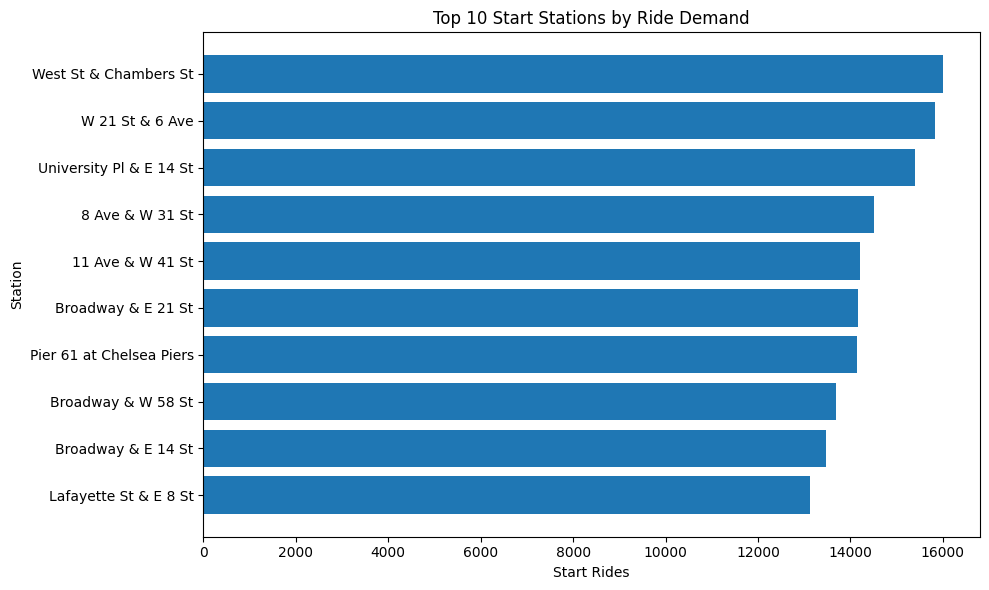

In [10]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_start_stations["station_name"][::-1],
    top_start_stations["start_rides"][::-1],
)

plt.title("Top 10 Start Stations by Ride Demand")
plt.xlabel("Start Rides")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

**观察与总结**

从起点次数看，`West St & Chambers St` 是取车需求最高的站点，起点骑行次数为16003次。其次是 `W 21 St & 6 Ave`，起点骑行次数为15820次；`University Pl & E 14 St` 为15405次。

这些站点属于高取车需求站点，说明用户从这些位置出发的需求较强。运营上需要关注这些站点在高峰时段是否容易出现车辆不足。

但高取车需求不等于一定缺车。例如 `West St & Chambers St` 的起点次数和终点次数都很高，净流入仅为-19，整体较为平衡。因此，是否需要调度还要结合后续的净流入指标判断。

## 8 分析高还车流入站点

本段按 `end_rides` 筛选终点次数最高的站点。终点次数越高，说明越多用户把车还到该站点，运营上需要关注该站点是否容易出现积车或满桩风险。

In [11]:
top_end_stations = (
    station_summary
    .sort_values("end_rides", ascending=False)
    .head(10)
)

display(top_end_stations)

,station_name,start_rides,station_lat,station_lng,end_rides,total_activity,net_inflow,abs_net_inflow,imbalance_ratio,imbalance_type
2145,West St & Chambers St,16003,40.717548,-74.013221,15984,31987,-19,19,-0.000594,net_outflow_shortage
2010,W 21 St & 6 Ave,15820,40.741740,-73.994156,15861,31681,41,41,0.001294,net_inflow_accumulation
1930,University Pl & E 14 St,15405,40.734814,-73.992085,15644,31049,239,239,0.007698,net_inflow_accumulation
447,8 Ave & W 31 St,14511,40.750585,-73.994685,14745,29256,234,234,0.007998,net_inflow_accumulation
1678,Pier 61 at Chelsea Piers,14144,40.746872,-74.008210,14233,28377,89,89,0.003136,net_inflow_accumulation
38,11 Ave & W 41 St,14200,40.760301,-73.998842,14212,28412,12,12,0.000422,net_inflow_accumulation
637,Broadway & E 21 St,14155,40.739888,-73.989586,14194,28349,39,39,0.001376,net_inflow_accumulation
635,Broadway & E 14 St,13471,40.734546,-73.990741,13326,26797,-145,145,-0.005411,net_outflow_shortage
672,Broadway & W 58 St,13697,40.766953,-73.981693,13228,26925,-469,469,-0.017419,net_outflow_shortage
1408,Lafayette St & E 8 St,13135,40.730207,-73.991026,13151,26286,16,16,0.000609,net_inflow_accumulation


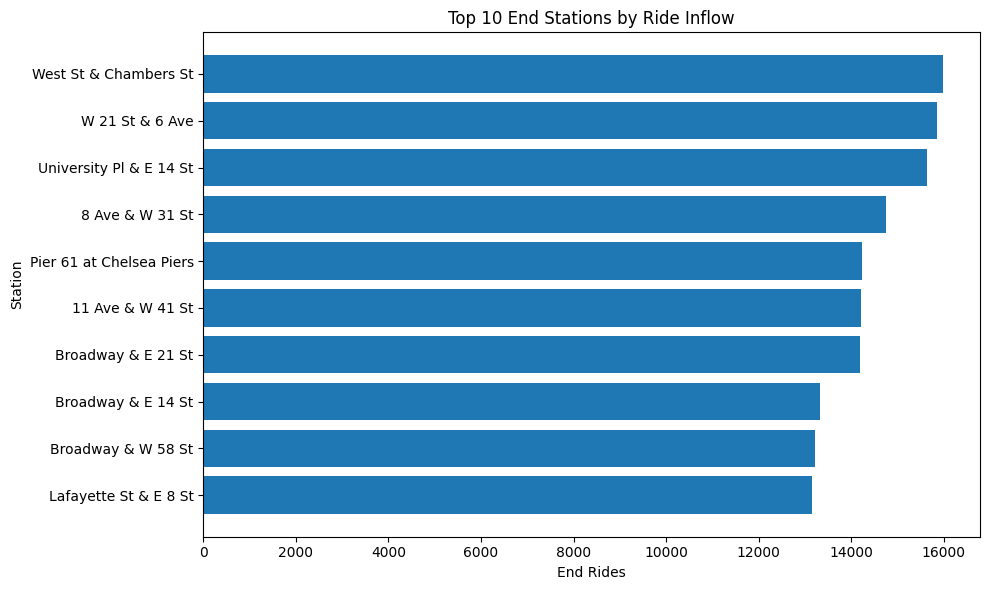

In [12]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_end_stations["station_name"][::-1],
    top_end_stations["end_rides"][::-1],
)

plt.title("Top 10 End Stations by Ride Inflow")
plt.xlabel("End Rides")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

**观察与总结**

从终点次数看，高还车流入站点与高取车需求站点高度重合。`West St & Chambers St` 的终点次数为15984次，仍然位居前列；`W 21 St & 6 Ave` 的终点次数为15861次；`University Pl & E 14 St` 的终点次数为15644次。

这说明部分核心站点既是高取车需求点，也是高还车流入点，属于系统中的高活跃枢纽站点。

因此，单独看起点次数或终点次数只能判断站点活跃度，不能直接判断缺车或积车风险。后续需要结合 `net_inflow` 判断车辆流入流出方向。

## 9 识别净流出站点：潜在缺车风险

本段筛选净流出绝对值最高的站点。`net_inflow < 0` 表示该站点作为起点的次数高于作为终点的次数，车辆被持续骑走，可能存在缺车风险。

In [13]:
top_net_outflow_stations = (
    station_summary
    .sort_values("net_inflow", ascending=True)
    .head(10)
)

display(top_net_outflow_stations)

,station_name,start_rides,station_lat,station_lng,end_rides,total_activity,net_inflow,abs_net_inflow,imbalance_ratio,imbalance_type
671,Broadway & W 56 St,7471,40.765265,-73.981923,6117,13588,-1354,1354,-0.099647,net_outflow_shortage
2073,W 59 St & 10 Ave,8017,40.770513,-73.988038,7304,15321,-713,713,-0.046537,net_outflow_shortage
1577,Murray St & West St,5163,40.715030,-74.012460,4496,9659,-667,667,-0.069055,net_outflow_shortage
2058,W 49 St & 8 Ave,5557,40.762272,-73.987882,4897,10454,-660,660,-0.063134,net_outflow_shortage
1316,Henry St & Grand St,7126,40.714211,-73.981095,6564,13690,-562,562,-0.041052,net_outflow_shortage
368,6 Ave & W 33 St,11963,40.749013,-73.988484,11441,23404,-522,522,-0.022304,net_outflow_shortage
672,Broadway & W 58 St,13697,40.766953,-73.981693,13228,26925,-469,469,-0.017419,net_outflow_shortage
673,Broadway & W 61 St,7611,40.770030,-73.981968,7144,14755,-467,467,-0.031650,net_outflow_shortage
1816,South St & Gouverneur Ln,4768,40.703554,-74.006702,4303,9071,-465,465,-0.051262,net_outflow_shortage
1051,E 44 St & 2 Ave,4126,40.751184,-73.971387,3674,7800,-452,452,-0.057949,net_outflow_shortage


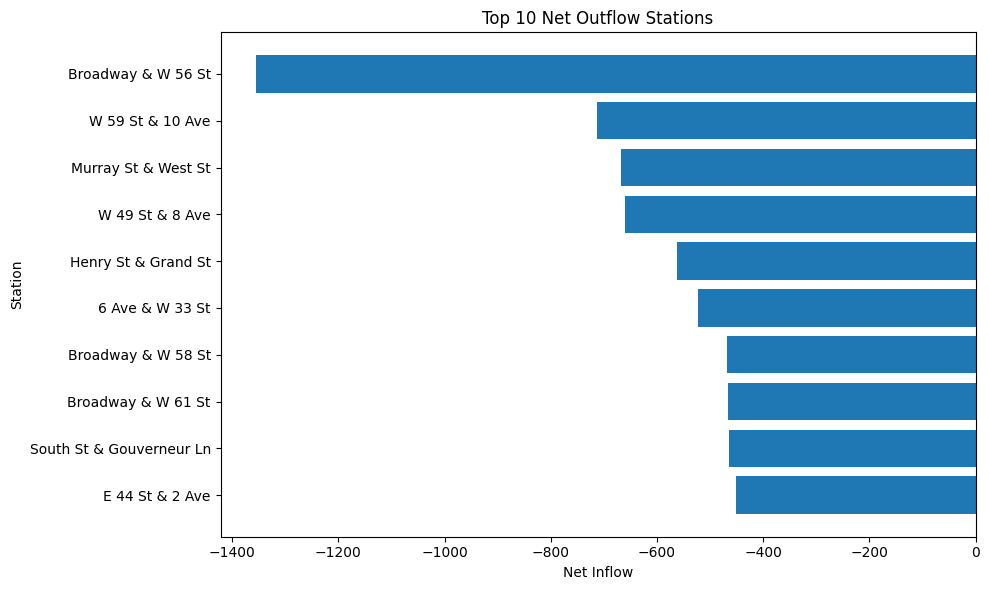

In [14]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_net_outflow_stations["station_name"][::-1],
    top_net_outflow_stations["net_inflow"][::-1],
)

plt.title("Top 10 Net Outflow Stations")
plt.xlabel("Net Inflow")
plt.ylabel("Station")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_top10_net_outflow_stations.png", dpi=150, bbox_inches="tight")
plt.show()

**观察与总结**

从净流出结果看，`Broadway & W 56 St` 是全日净流出最明显的站点，`net_inflow` 为-1354，表示该站点作为起点的次数比作为终点的次数多1354次，存在较强的潜在缺车风险。

其次是 `W 59 St & 10 Ave`，净流出为-713；`Murray St & West St` 净流出为-667；`W 49 St & 8 Ave` 净流出为-660。

这些站点的共同特征是起点需求明显高于终点流入，车辆持续被用户骑走。运营上可以将这类站点作为补车候选，尤其需要关注高峰时段是否出现无车可借的问题。

## 10 识别净流入站点：潜在积车风险

本段筛选净流入最高的站点。`net_inflow > 0` 表示该站点作为终点的次数高于作为起点的次数，车辆持续流入，可能存在积车或满桩风险。

In [15]:
top_net_inflow_stations = (
    station_summary
    .sort_values("net_inflow", ascending=False)
    .head(10)
)

display(top_net_inflow_stations)

,station_name,start_rides,station_lat,station_lng,end_rides,total_activity,net_inflow,abs_net_inflow,imbalance_ratio,imbalance_type
1576,Murray St & Greenwich St,5041,40.714852,-74.011223,5726,10767,685,685,0.063620,net_inflow_accumulation
39,11 Ave & W 59 St,6534,40.771497,-73.990460,7124,13658,590,590,0.043198,net_inflow_accumulation
1633,Old Slip & South St,3887,40.703367,-74.007868,4304,8191,417,417,0.050910,net_inflow_accumulation
669,Broadway & W 51 St,6141,40.762288,-73.983362,6556,12697,415,415,0.032685,net_inflow_accumulation
2069,W 55 St & 6 Ave,5582,40.763189,-73.978434,5977,11559,395,395,0.034173,net_inflow_accumulation
1331,Hudson St & Reade St,3701,40.716250,-74.009106,4076,7777,375,375,0.048219,net_inflow_accumulation
951,E 14 St & 1 Ave,7787,40.731393,-73.982867,8101,15888,314,314,0.019763,net_inflow_accumulation
2142,West End Ave & W 60 St,8885,40.772370,-73.990050,9198,18083,313,313,0.017309,net_inflow_accumulation
555,Ave A & E 11 St,6551,40.728547,-73.981759,6845,13396,294,294,0.021947,net_inflow_accumulation
2033,W 34 St & Hudson Blvd E,10800,40.755167,-74.000599,11077,21877,277,277,0.012662,net_inflow_accumulation


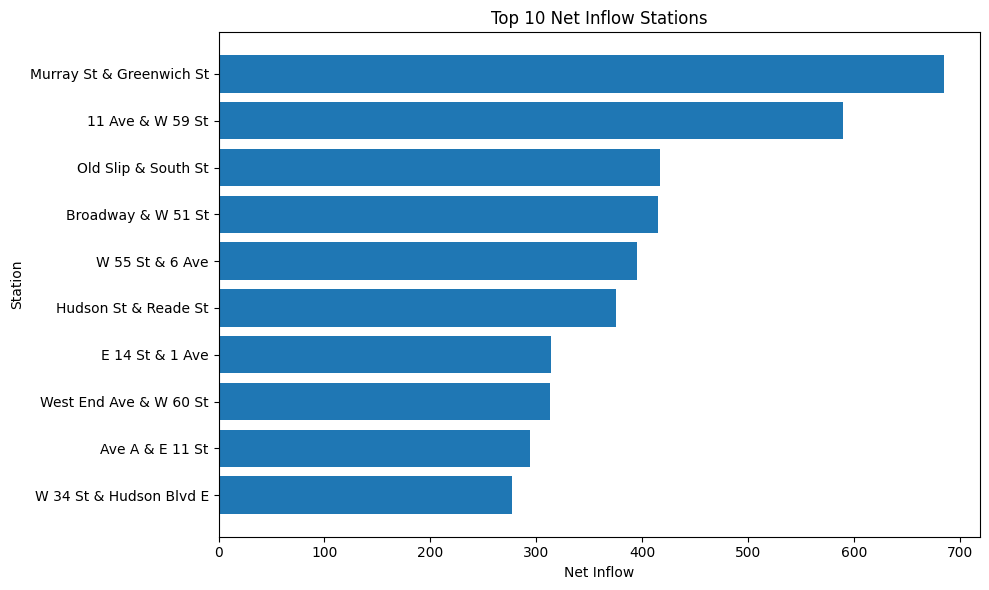

In [16]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_net_inflow_stations["station_name"][::-1],
    top_net_inflow_stations["net_inflow"][::-1],
)

plt.title("Top 10 Net Inflow Stations")
plt.xlabel("Net Inflow")
plt.ylabel("Station")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_top10_net_inflow_stations.png", dpi=150, bbox_inches="tight")
plt.show()

**观察与总结**

从净流入结果看，`Murray St & Greenwich St` 是全日净流入最高的站点，`net_inflow` 为685，表示该站点作为终点的次数比作为起点的次数多685次，存在潜在积车或满桩风险。

其次是 `11 Ave & W 59 St`，净流入为590；`Old Slip & South St` 净流入为417；`Broadway & W 51 St` 净流入为415。

这些站点的车辆流入明显高于流出，运营上需要关注是否出现车辆堆积、停车桩紧张或还车困难。与净流出站点相反，这类站点更适合安排清运或向周边缺车站点调拨车辆。

## 11 筛选高活跃且高失衡站点

单纯看净流入或净流出，可能会受到低活跃站点小样本波动影响。因此，本段设置最低站点活动量门槛，只在活跃度足够的站点中识别失衡最明显的站点。

这里将 `total_activity >= 1000` 作为筛选条件，用于减少低样本站点带来的噪声。

In [17]:
min_total_activity = 1000

active_station_summary = station_summary[
    station_summary["total_activity"] >= min_total_activity
].copy()

priority_shortage_stations = (
    active_station_summary[
        active_station_summary["net_inflow"] < 0
    ]
    .sort_values("abs_net_inflow", ascending=False)
    .head(10)
)

priority_accumulation_stations = (
    active_station_summary[
        active_station_summary["net_inflow"] > 0
    ]
    .sort_values("abs_net_inflow", ascending=False)
    .head(10)
)

display(priority_shortage_stations)
display(priority_accumulation_stations)

,station_name,start_rides,station_lat,station_lng,end_rides,total_activity,net_inflow,abs_net_inflow,imbalance_ratio,imbalance_type
671,Broadway & W 56 St,7471,40.765265,-73.981923,6117,13588,-1354,1354,-0.099647,net_outflow_shortage
2073,W 59 St & 10 Ave,8017,40.770513,-73.988038,7304,15321,-713,713,-0.046537,net_outflow_shortage
1577,Murray St & West St,5163,40.715030,-74.012460,4496,9659,-667,667,-0.069055,net_outflow_shortage
2058,W 49 St & 8 Ave,5557,40.762272,-73.987882,4897,10454,-660,660,-0.063134,net_outflow_shortage
1316,Henry St & Grand St,7126,40.714211,-73.981095,6564,13690,-562,562,-0.041052,net_outflow_shortage
368,6 Ave & W 33 St,11963,40.749013,-73.988484,11441,23404,-522,522,-0.022304,net_outflow_shortage
672,Broadway & W 58 St,13697,40.766953,-73.981693,13228,26925,-469,469,-0.017419,net_outflow_shortage
673,Broadway & W 61 St,7611,40.770030,-73.981968,7144,14755,-467,467,-0.031650,net_outflow_shortage
1816,South St & Gouverneur Ln,4768,40.703554,-74.006702,4303,9071,-465,465,-0.051262,net_outflow_shortage
1051,E 44 St & 2 Ave,4126,40.751184,-73.971387,3674,7800,-452,452,-0.057949,net_outflow_shortage


,station_name,start_rides,station_lat,station_lng,end_rides,total_activity,net_inflow,abs_net_inflow,imbalance_ratio,imbalance_type
1576,Murray St & Greenwich St,5041,40.714852,-74.011223,5726,10767,685,685,0.063620,net_inflow_accumulation
39,11 Ave & W 59 St,6534,40.771497,-73.990460,7124,13658,590,590,0.043198,net_inflow_accumulation
1633,Old Slip & South St,3887,40.703367,-74.007868,4304,8191,417,417,0.050910,net_inflow_accumulation
669,Broadway & W 51 St,6141,40.762288,-73.983362,6556,12697,415,415,0.032685,net_inflow_accumulation
2069,W 55 St & 6 Ave,5582,40.763189,-73.978434,5977,11559,395,395,0.034173,net_inflow_accumulation
1331,Hudson St & Reade St,3701,40.716250,-74.009106,4076,7777,375,375,0.048219,net_inflow_accumulation
951,E 14 St & 1 Ave,7787,40.731393,-73.982867,8101,15888,314,314,0.019763,net_inflow_accumulation
2142,West End Ave & W 60 St,8885,40.772370,-73.990050,9198,18083,313,313,0.017309,net_inflow_accumulation
555,Ave A & E 11 St,6551,40.728547,-73.981759,6845,13396,294,294,0.021947,net_inflow_accumulation
2033,W 34 St & Hudson Blvd E,10800,40.755167,-74.000599,11077,21877,277,277,0.012662,net_inflow_accumulation


**观察与总结**

本节设置 `total_activity >= 1000` 的门槛，只在高活跃站点中筛选失衡站点，避免低活跃站点因为少量骑行记录产生较大的偶然波动。

在高活跃站点中，缺车风险最高的站点仍然是 `Broadway & W 56 St`，净流出为-1354；其次是 `W 59 St & 10 Ave`、`Murray St & West St` 和 `W 49 St & 8 Ave`。这些站点不仅失衡明显，而且整体活动量较高，因此更适合作为补车优先级候选。

积车风险最高的高活跃站点是 `Murray St & Greenwich St`，净流入为685；其次是 `11 Ave & W 59 St`、`Old Slip & South St` 和 `Broadway & W 51 St`。这些站点可以作为清运或车辆外调候选。

这一节相比前面的Top10更接近运营优先级判断：不是只看净流入大小，而是在活跃度足够的站点中识别真正值得调度关注的站点。

## 12 分析晚高峰站点失衡

03 中已经发现，晚高峰是本月单位时间需求强度最高的时段。因此，本段单独筛选 `evening_peak` 时段，分析晚高峰下哪些站点存在明显净流入或净流出。

该结果更接近实际调度场景，因为运营补车和清运通常需要针对特定高峰时段安排。

In [18]:
evening_base = station_base[
    station_base["time_period"] == "evening_peak"
].copy()

evening_station_summary = build_station_imbalance_summary(evening_base)

evening_station_summary_check = pd.Series(
    {
        "stations": len(evening_station_summary),
        "total_start_rides": evening_station_summary["start_rides"].sum(),
        "total_end_rides": evening_station_summary["end_rides"].sum(),
        "total_activity": evening_station_summary["total_activity"].sum(),
        "net_inflow_sum": evening_station_summary["net_inflow"].sum(),
    }
).to_frame("value")

display(evening_station_summary.head())
display(evening_station_summary_check)

,station_name,start_rides,station_lat,station_lng,end_rides,total_activity,net_inflow,abs_net_inflow,imbalance_ratio,imbalance_type
0,1 Ave & E 110 St,797,40.792327,-73.938300,880,1677,83,83,0.049493,net_inflow_accumulation
1,1 Ave & E 118 St,581,40.797459,-73.934499,725,1306,144,144,0.110260,net_inflow_accumulation
2,1 Ave & E 16 St,1923,40.732219,-73.981656,2258,4181,335,335,0.080124,net_inflow_accumulation
3,1 Ave & E 18 St,2380,40.733812,-73.980544,2964,5344,584,584,0.109281,net_inflow_accumulation
4,1 Ave & E 30 St,1363,40.741444,-73.975361,1086,2449,-277,277,-0.113107,net_outflow_shortage


,value
stations,2178
total_start_rides,1547616
total_end_rides,1547616
total_activity,3095232
net_inflow_sum,0


**观察与总结**

晚高峰站点汇总表共包含2178个业务站点。晚高峰时段起点骑行次数合计为1547616，终点骑行次数合计同样为1547616，`net_inflow_sum` 为0，说明晚高峰样本在全局层面同样保持流入流出闭合。

与全日口径相比，晚高峰更接近实际调度压力。因为03中已经发现，晚高峰是本月单位时间需求强度最高的时段，因此该时段的站点净流入和净流出更适合用于制定高峰期补车与清运策略。

In [19]:
evening_min_total_activity = 300

evening_active_station_summary = evening_station_summary[
    evening_station_summary["total_activity"] >= evening_min_total_activity
].copy()

evening_priority_shortage_stations = (
    evening_active_station_summary[
        evening_active_station_summary["net_inflow"] < 0
    ]
    .sort_values("abs_net_inflow", ascending=False)
    .head(10)
)

evening_priority_accumulation_stations = (
    evening_active_station_summary[
        evening_active_station_summary["net_inflow"] > 0
    ]
    .sort_values("abs_net_inflow", ascending=False)
    .head(10)
)

display(evening_priority_shortage_stations)
display(evening_priority_accumulation_stations)

,station_name,start_rides,station_lat,station_lng,end_rides,total_activity,net_inflow,abs_net_inflow,imbalance_ratio,imbalance_type
1052,E 47 St & Park Ave,3906,40.755103,-73.974987,1116,5022,-2790,2790,-0.555556,net_outflow_shortage
1608,North Moore St & Greenwich St,4332,40.720195,-74.010301,1949,6281,-2383,2383,-0.379398,net_outflow_shortage
10,1 Ave & E 68 St,4872,40.765005,-73.958185,2494,7366,-2378,2378,-0.322835,net_outflow_shortage
1282,Greenwich St & Hubert St,2587,40.721319,-74.010065,548,3135,-2039,2039,-0.650399,net_outflow_shortage
894,Dock 72 Way & Market St,1843,40.699850,-73.971410,130,1973,-1713,1713,-0.868221,net_outflow_shortage
1043,E 40 St & Park Ave,4422,40.750756,-73.978326,2835,7257,-1587,1587,-0.218685,net_outflow_shortage
660,Broadway & W 25 St,4908,40.742869,-73.989186,3453,8361,-1455,1455,-0.174022,net_outflow_shortage
669,Broadway & W 56 St,2670,40.765265,-73.981923,1293,3963,-1377,1377,-0.347464,net_outflow_shortage
1042,E 40 St & 5 Ave,3263,40.752062,-73.981632,1891,5154,-1372,1372,-0.266201,net_outflow_shortage
1044,E 41 St & Madison Ave (SE corner),2971,40.752049,-73.979635,1644,4615,-1327,1327,-0.287541,net_outflow_shortage


,station_name,start_rides,station_lat,station_lng,end_rides,total_activity,net_inflow,abs_net_inflow,imbalance_ratio,imbalance_type
1723,Riverside Blvd & W 67 St,2448,40.777507,-73.988886,3756,6204,1308,1308,0.210832,net_inflow_accumulation
8,1 Ave & E 6 St,1948,40.726331,-73.986169,2904,4852,956,956,0.197032,net_inflow_accumulation
2034,W 43 St & 10 Ave,3224,40.760094,-73.994618,4179,7403,955,955,0.129002,net_inflow_accumulation
51,12 Ave & W 40 St,4484,40.760875,-74.002777,5329,9813,845,845,0.086110,net_inflow_accumulation
912,E 10 St & Ave A,2164,40.727408,-73.981420,2990,5154,826,826,0.160264,net_inflow_accumulation
2128,West End Ave & W 60 St,3037,40.772370,-73.990050,3851,6888,814,814,0.118177,net_inflow_accumulation
1877,Suffolk St & Stanton St,2400,40.720664,-73.985180,3205,5605,805,805,0.143622,net_inflow_accumulation
766,Christopher St & Greenwich St,3091,40.732916,-74.007114,3887,6978,796,796,0.114073,net_inflow_accumulation
1835,St Marks Pl & 2 Ave,2032,40.728419,-73.987140,2818,4850,786,786,0.162062,net_inflow_accumulation
2028,W 4 St & 7 Ave S,2956,40.734011,-74.002939,3723,6679,767,767,0.114838,net_inflow_accumulation


**观察与总结**

晚高峰下的站点失衡比全日口径更加明显。缺车风险方面，`E 47 St & Park Ave` 的净流出达到-2790，是晚高峰最突出的净流出站点；`North Moore St & Greenwich St` 净流出为-2383；`1 Ave & E 68 St` 净流出为-2378；`Greenwich St & Hubert St` 净流出为-2039。

这些站点在晚高峰时段车辆被大量骑走，说明如果运营侧只看全日平衡，可能会低估高峰时段的短时缺车压力。

积车风险方面，`Riverside Blvd & W 67 St` 晚高峰净流入为1308，是晚高峰最明显的净流入站点；`1 Ave & E 6 St` 和 `W 43 St & 10 Ave` 净流入均接近千次。此类站点在晚高峰可能出现车辆集中还入，运营上需要关注满桩或清运压力。

因此，高峰期调度不能只依赖全日净流入结果。晚高峰单独分析能够更直接地识别短时间内的车辆供需失衡。

## 13 导出站点失衡分析结果

本段导出全日站点失衡汇总表和晚高峰站点失衡汇总表，供后续 Power BI 看板和 README 图表展示使用。

In [20]:
station_summary_path = DATA_CLEAN_DIR / "station_imbalance_202407.csv"
evening_station_summary_path = DATA_CLEAN_DIR / "evening_station_imbalance_202407.csv"

station_summary.to_csv(station_summary_path, index=False)
evening_station_summary.to_csv(evening_station_summary_path, index=False)

print("已导出:", station_summary_path)
print("记录数:", len(station_summary))

print("已导出:", evening_station_summary_path)
print("记录数:", len(evening_station_summary))

已导出: ..\data_clean\station_imbalance_202407.csv
记录数: 2194
已导出: ..\data_clean\evening_station_imbalance_202407.csv
记录数: 2178


**观察与总结**

全日站点失衡汇总表已导出为 `station_imbalance_202407.csv`，共包含2194个业务站点。

晚高峰站点失衡汇总表已导出为 `evening_station_imbalance_202407.csv`，共包含2178个业务站点。

这两张表将作为后续Power BI看板和README核心图表的数据基础。全日表适合展示整体站点失衡格局，晚高峰表适合展示高峰期调度压力。

## 总结

本 Notebook 基于 `trip_base_202407.csv` 中起点站和终点站字段完整的记录，分析了 Citi Bike 站点层面的取车需求、还车流入和流入流出失衡情况。

首先，本 Notebook 检查了 `station_id` 与 `station_name` 的对应关系。结果显示，`station_id` 对应多个 `station_name` 的情况较少，仅有2个；但 `station_name` 对应多个 `station_id` 的情况相对更多，共有94个站点名称存在多个站点ID。经纬度检查显示，大多数同名多ID站点的位置差异很小，说明这些情况更可能来自站点ID版本、重新编号或数据记录方式差异。

因此，本项目在站点运营分析中采用 `station_name` 作为业务站点口径，而不是直接使用 `station_id`。这样可以避免同一个业务站点被多个ID拆分，导致取车需求、还车流入和净流入指标被分散。`station_id` 在本项目中主要用于数据质量检查，`station_name` 用于站点运营分析和图表展示。

基于站点名称口径，全日站点汇总表共包含2194个业务站点。起点骑行次数合计为4706967，终点骑行次数合计同样为4706967，`net_inflow_sum` 为0，说明全局层面的起点与终点统计口径闭合。系统整体净流入为0并不代表单个站点平衡，因此后续重点关注单站点的 `net_inflow`。

从高活跃站点看，`West St & Chambers St`、`W 21 St & 6 Ave`、`University Pl & E 14 St` 等站点同时具有较高取车需求和还车流入，是Citi Bike系统中的高活跃枢纽站点。但这些站点不一定都是高失衡站点，因此不能只根据骑行总量判断调度优先级。

从全日净流出看，`Broadway & W 56 St` 是最明显的潜在缺车风险站点，净流出为-1354；其次包括 `W 59 St & 10 Ave`、`Murray St & West St` 和 `W 49 St & 8 Ave`。这些站点车辆被骑走的次数明显多于被还回的次数，适合作为补车候选站点。

从全日净流入看，`Murray St & Greenwich St` 是最明显的潜在积车风险站点，净流入为685；其次包括 `11 Ave & W 59 St`、`Old Slip & South St` 和 `Broadway & W 51 St`。这些站点车辆还入明显多于取出，适合作为清运或车辆外调候选站点。

为了降低低活跃站点带来的小样本波动，本 Notebook 进一步设置 `total_activity >= 1000` 的门槛，在高活跃站点中筛选缺车风险和积车风险站点。该处理使结果更接近实际运营优先级，而不是单纯的统计排序。

结合03中的需求规律分析，本 Notebook 单独分析了晚高峰站点失衡情况。晚高峰站点汇总表共包含2178个业务站点，起点骑行次数和终点骑行次数均为1547616，整体口径同样闭合。晚高峰下的失衡程度比全日口径更加明显：`E 47 St & Park Ave` 晚高峰净流出达到-2790，`North Moore St & Greenwich St` 净流出为-2383，`1 Ave & E 68 St` 净流出为-2378；而 `Riverside Blvd & W 67 St` 晚高峰净流入为1308。

综合来看，Citi Bike的站点运营不能只看站点总骑行量，还需要同时关注流入流出方向和高峰时段失衡。全日口径适合识别整体缺车或积车倾向，晚高峰口径更适合识别短时间内的调度压力。后续运营策略可以将高活跃且高净流出的站点作为补车优先候选，将高活跃且高净流入的站点作为清运或车辆外调候选。

下一步将在 `05_member_casual_behavior_analysis.ipynb` 中，进一步比较会员用户和临时用户在骑行时长、时段分布、车型偏好和站点使用上的差异，判断不同用户类型是否对应不同的使用场景。